# Maximal Lotteries

## Set-up

In [1]:
from utils_3 import PairwiseData, Population

In [2]:
import os
for k in ["HF_HOME", "HF_HUB_CACHE", "HF_DATASETS_CACHE", "XDG_CACHE_HOME"]:
    print(k, os.environ.get(k))

HF_HOME /home/jennifer/scratch/hf
HF_HUB_CACHE None
HF_DATASETS_CACHE /home/jennifer/scratch/hf/datasets
XDG_CACHE_HOME None


In [3]:
from datasets import load_dataset

ds = load_dataset(
    "lmarena-ai/arena-human-preference-140k") 
ds = dict(ds)

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)
candidate_labels = [pw.idx_to_candidates[i] for i in range(len(pw.idx_to_candidates))]

100%|██████████| 30/30 [00:00<00:00, 34.74it/s]


## Setting up maximal lotteries

In [5]:
import numpy as np
from scipy.optimize import linprog


def maximal_lottery_from_pairwise(winners, losers, n_items=None, tie_tol=1e-12):
    """
    Compute a maximal lottery from pairwise comparison outcomes.

    Parameters
    ----------
    winners, losers : array-like of int
        winners[k] beat losers[k].
    n_items : int, optional
        Number of candidates. If omitted, inferred from winners/losers.
    tie_tol : float
        Small probabilities below this are rounded to zero.

    Returns
    -------
    lottery : np.ndarray, shape (n_items,)
        Maximal-lottery distribution over candidates.
    ranking : np.ndarray
        Candidates sorted by decreasing lottery mass.
    winner : int
        Candidate with largest maximal-lottery probability.
    margins : np.ndarray, shape (n_items, n_items)
        Majority-margin matrix M where M[i, j] = wins(i over j) - wins(j over i).
    """
    winners = np.asarray(winners, dtype=int)
    losers = np.asarray(losers, dtype=int)

    if winners.shape != losers.shape:
        raise ValueError("winners and losers must have the same shape.")

    if winners.size == 0:
        raise ValueError("winners/losers cannot be empty.")

    if n_items is None:
        n_items = int(max(winners.max(), losers.max()) + 1)

    # Build majority-margin matrix.
    margins = np.zeros((n_items, n_items), dtype=float)
    for w, l in zip(winners, losers):
        if w == l:
            continue
        margins[w, l] += 1.0
        margins[l, w] -= 1.0

    # Maximal lottery LP:
    # find p >= 0, sum p = 1, such that margins.T @ p >= 0
    result = linprog(
        c=np.zeros(n_items, dtype=float),
        A_ub=-margins.T,
        b_ub=np.zeros(n_items, dtype=float),
        A_eq=np.ones((1, n_items), dtype=float),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * n_items,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(f"Maximal lottery solve failed: {result.message}")

    lottery = np.asarray(result.x, dtype=float)
    lottery[np.abs(lottery) < tie_tol] = 0.0
    lottery /= lottery.sum()

    ranking = np.argsort(-lottery)
    winner = int(ranking[0])
    return lottery, ranking, winner, margins


In [6]:
import matplotlib.pyplot as plt

/tmp/ipykernel_391500/1318931809.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


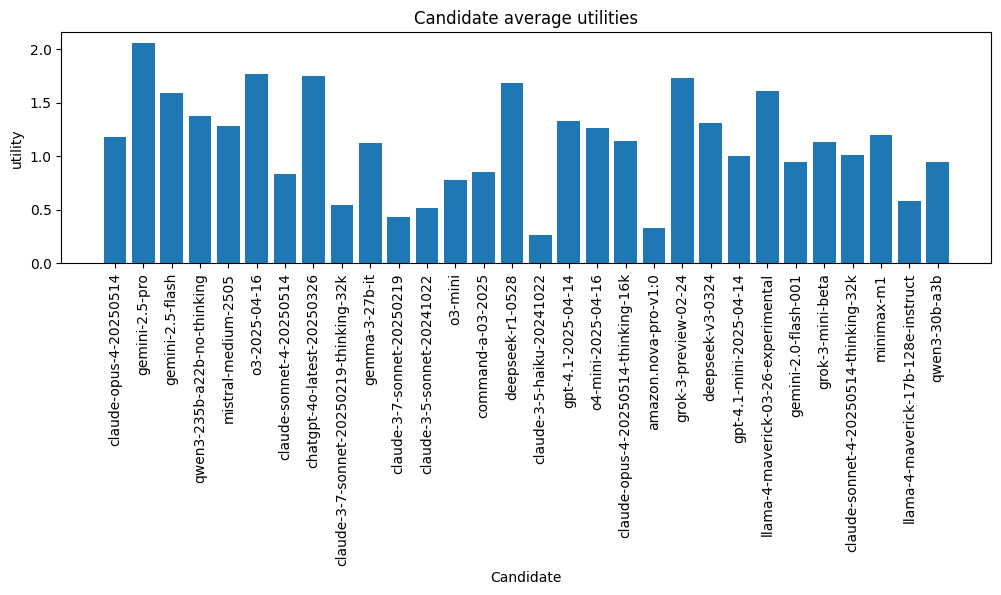

In [7]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), population.avg_utilities)
    ax.set_title(f'Candidate average utilities')
    ax.set_ylabel('utility')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [8]:
true_ranking = np.argsort(-population.avg_utilities)

/tmp/ipykernel_391500/397393443.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


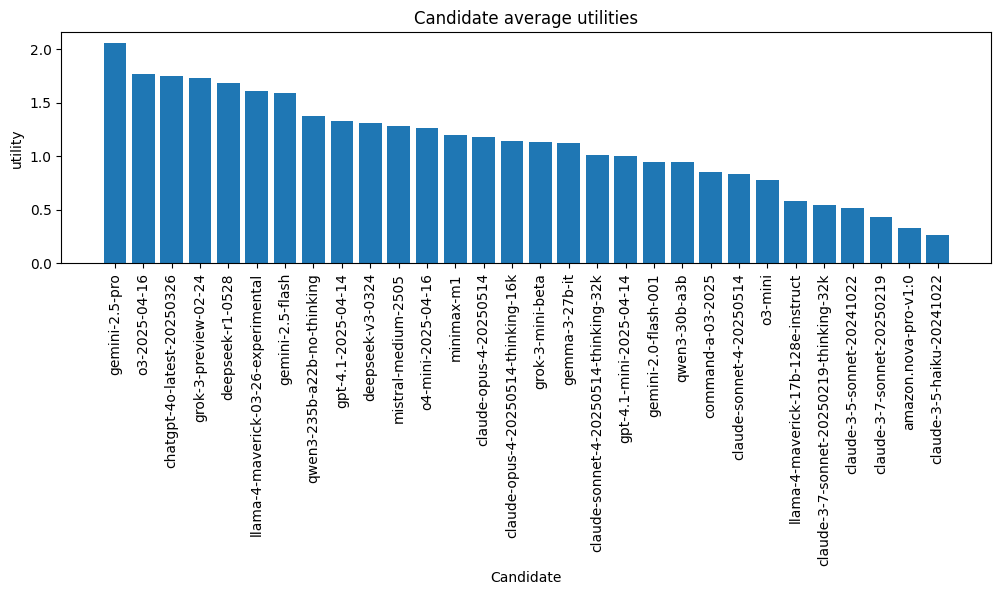

In [9]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

sorted_candidate_labels = [candidate_labels[i] for i in true_ranking]

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), population.avg_utilities[true_ranking])
    ax.set_title(f'Candidate average utilities')
    ax.set_ylabel('utility')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(sorted_candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [10]:
lottery, ranking, winner, margins = maximal_lottery_from_pairwise(pw.winners, pw.losers, pw.M)

In [11]:
print(winner)
print(lottery.shape)
print(lottery.sum())

1
(30,)
1.0


/tmp/ipykernel_391500/4289048897.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


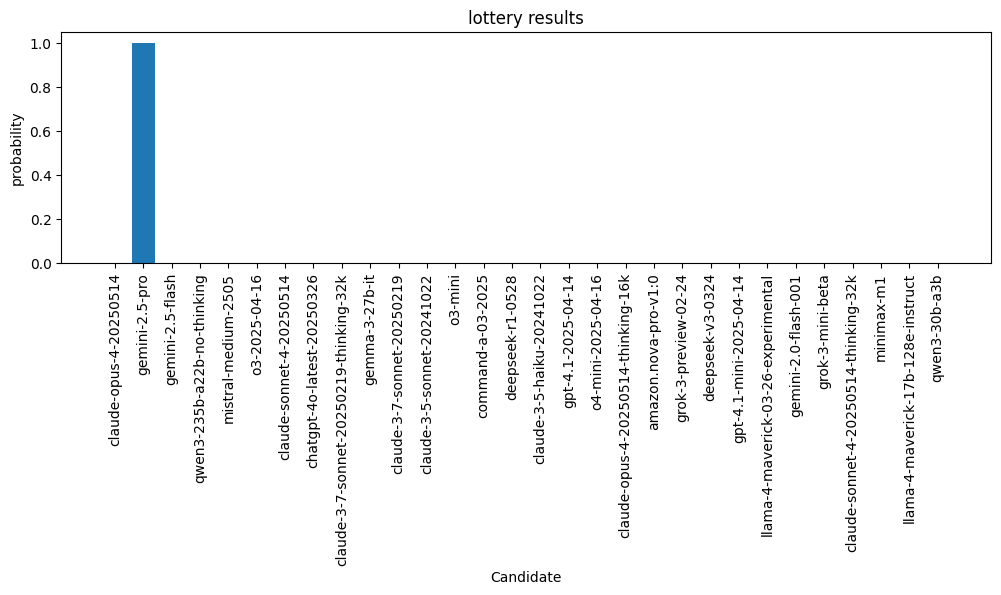

In [12]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), lottery)
    ax.set_title(f'lottery results')
    ax.set_ylabel('probability')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [13]:
data = pw.data_by_subgroups([1533])
winners = data['winners']
losers = data['losers']

In [27]:
winners.shape

(3009,)

In [14]:
lottery, ranking, winner, margins = maximal_lottery_from_pairwise(winners, losers, pw.M)
winner

7

In [15]:
print(lottery.shape)
print(lottery.sum())

(30,)
1.0


/tmp/ipykernel_391500/4289048897.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


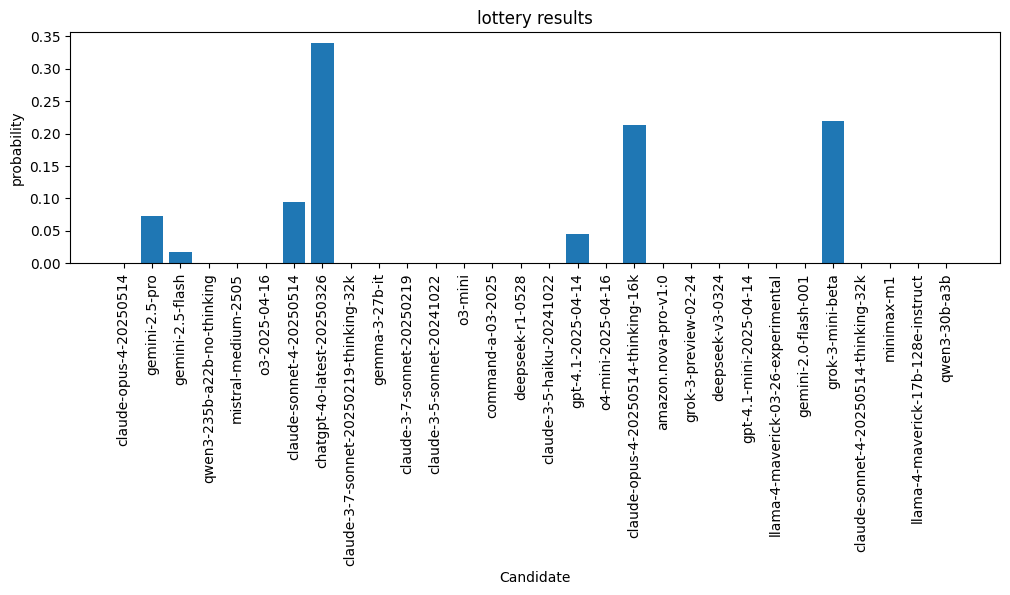

In [16]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), lottery)
    ax.set_title(f'lottery results')
    ax.set_ylabel('probability')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [53]:
winners = pw.winners
losers = pw.losers

In [54]:
ij_wins = np.zeros((pw.M, pw.M))

for i in range(len(winners)):
    ij_wins[winners[i], losers[i]] += 1

In [55]:
margin_wins = (ij_wins - ij_wins.T) / (ij_wins + ij_wins.T)

/tmp/ipykernel_391500/2038661105.py:1: RuntimeWarning: invalid value encountered in divide
  margin_wins = (ij_wins - ij_wins.T) / (ij_wins + ij_wins.T)


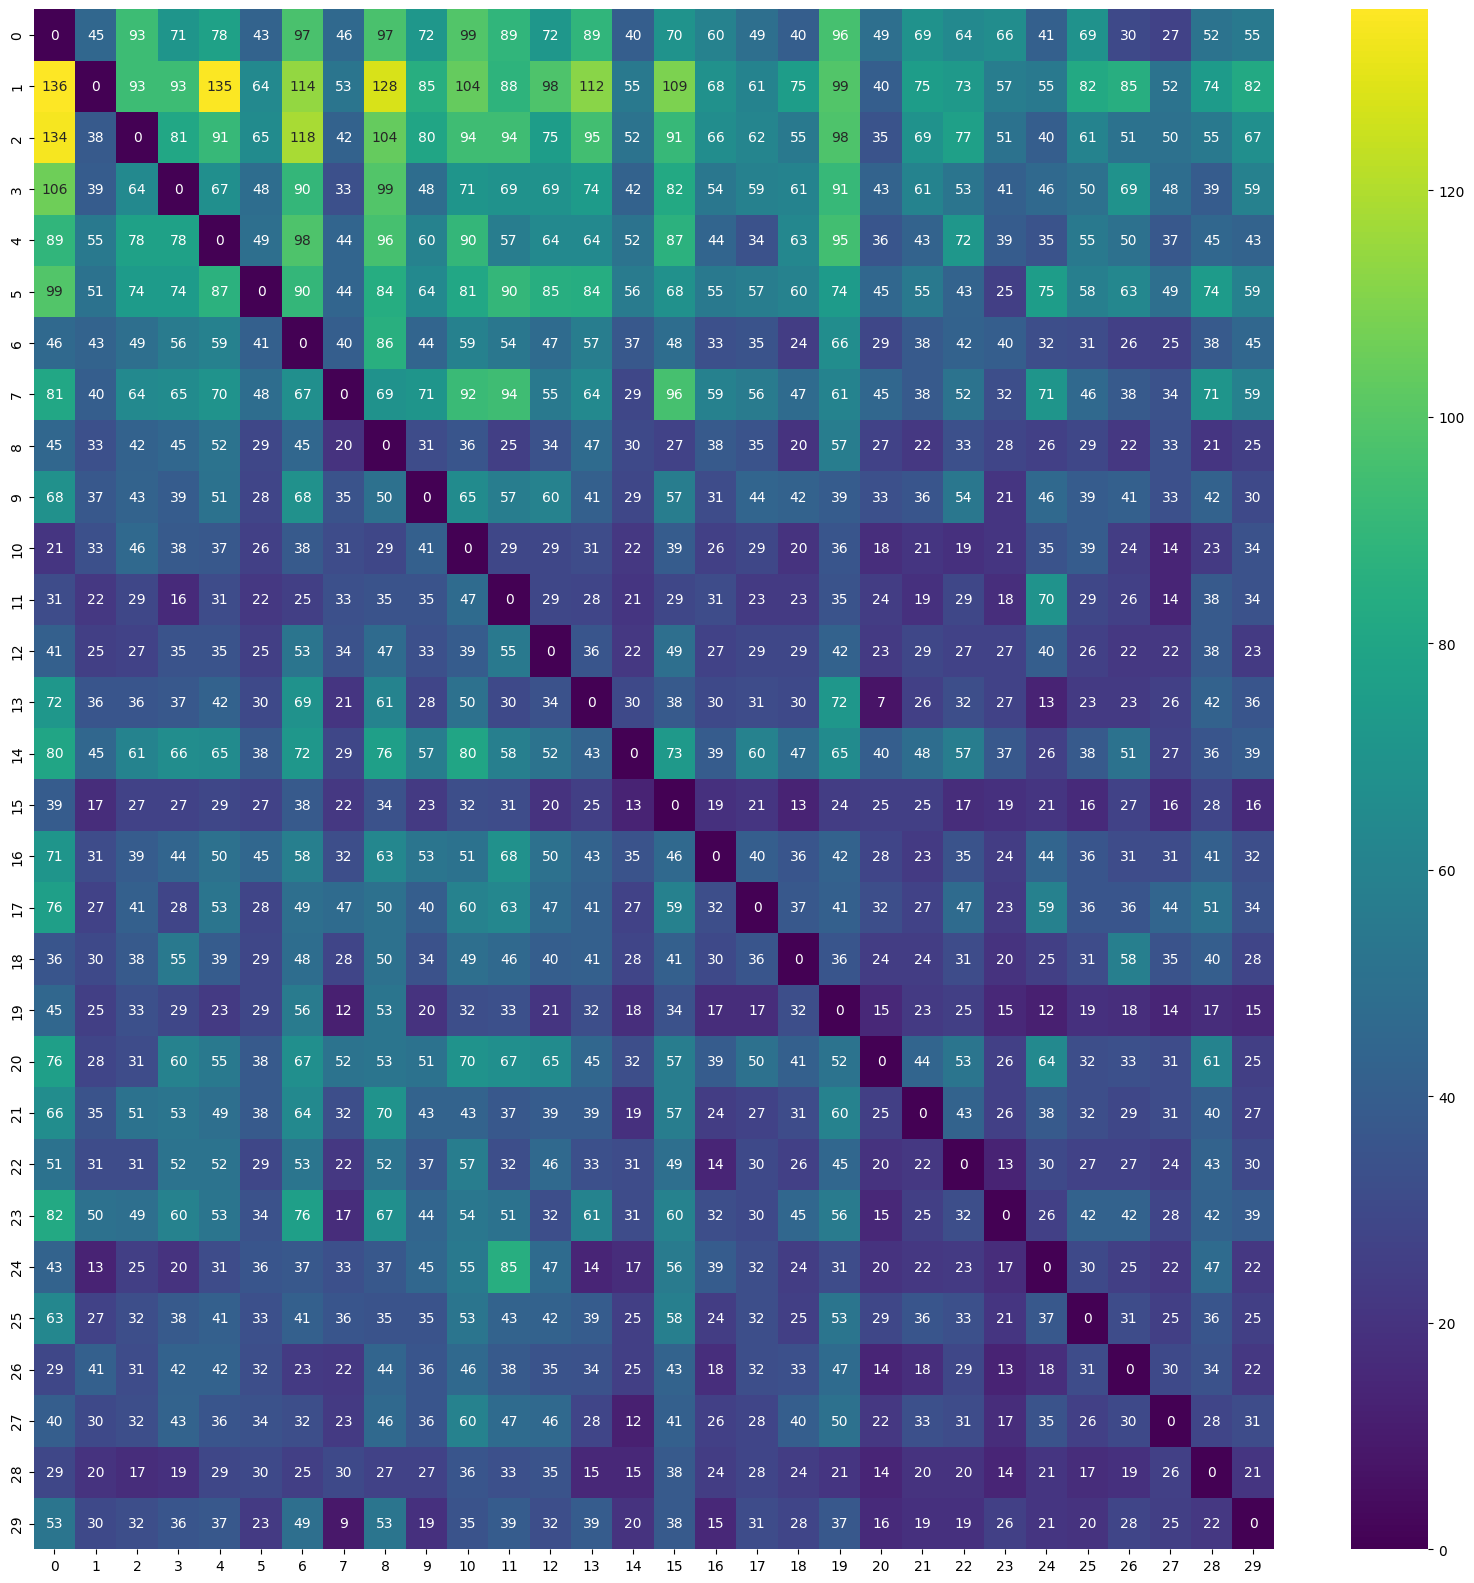

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
sns.heatmap(
    ij_wins,
    annot=True,      # show numbers in cells
    fmt=".0f",       # number format
    cmap="viridis"
)
plt.show()

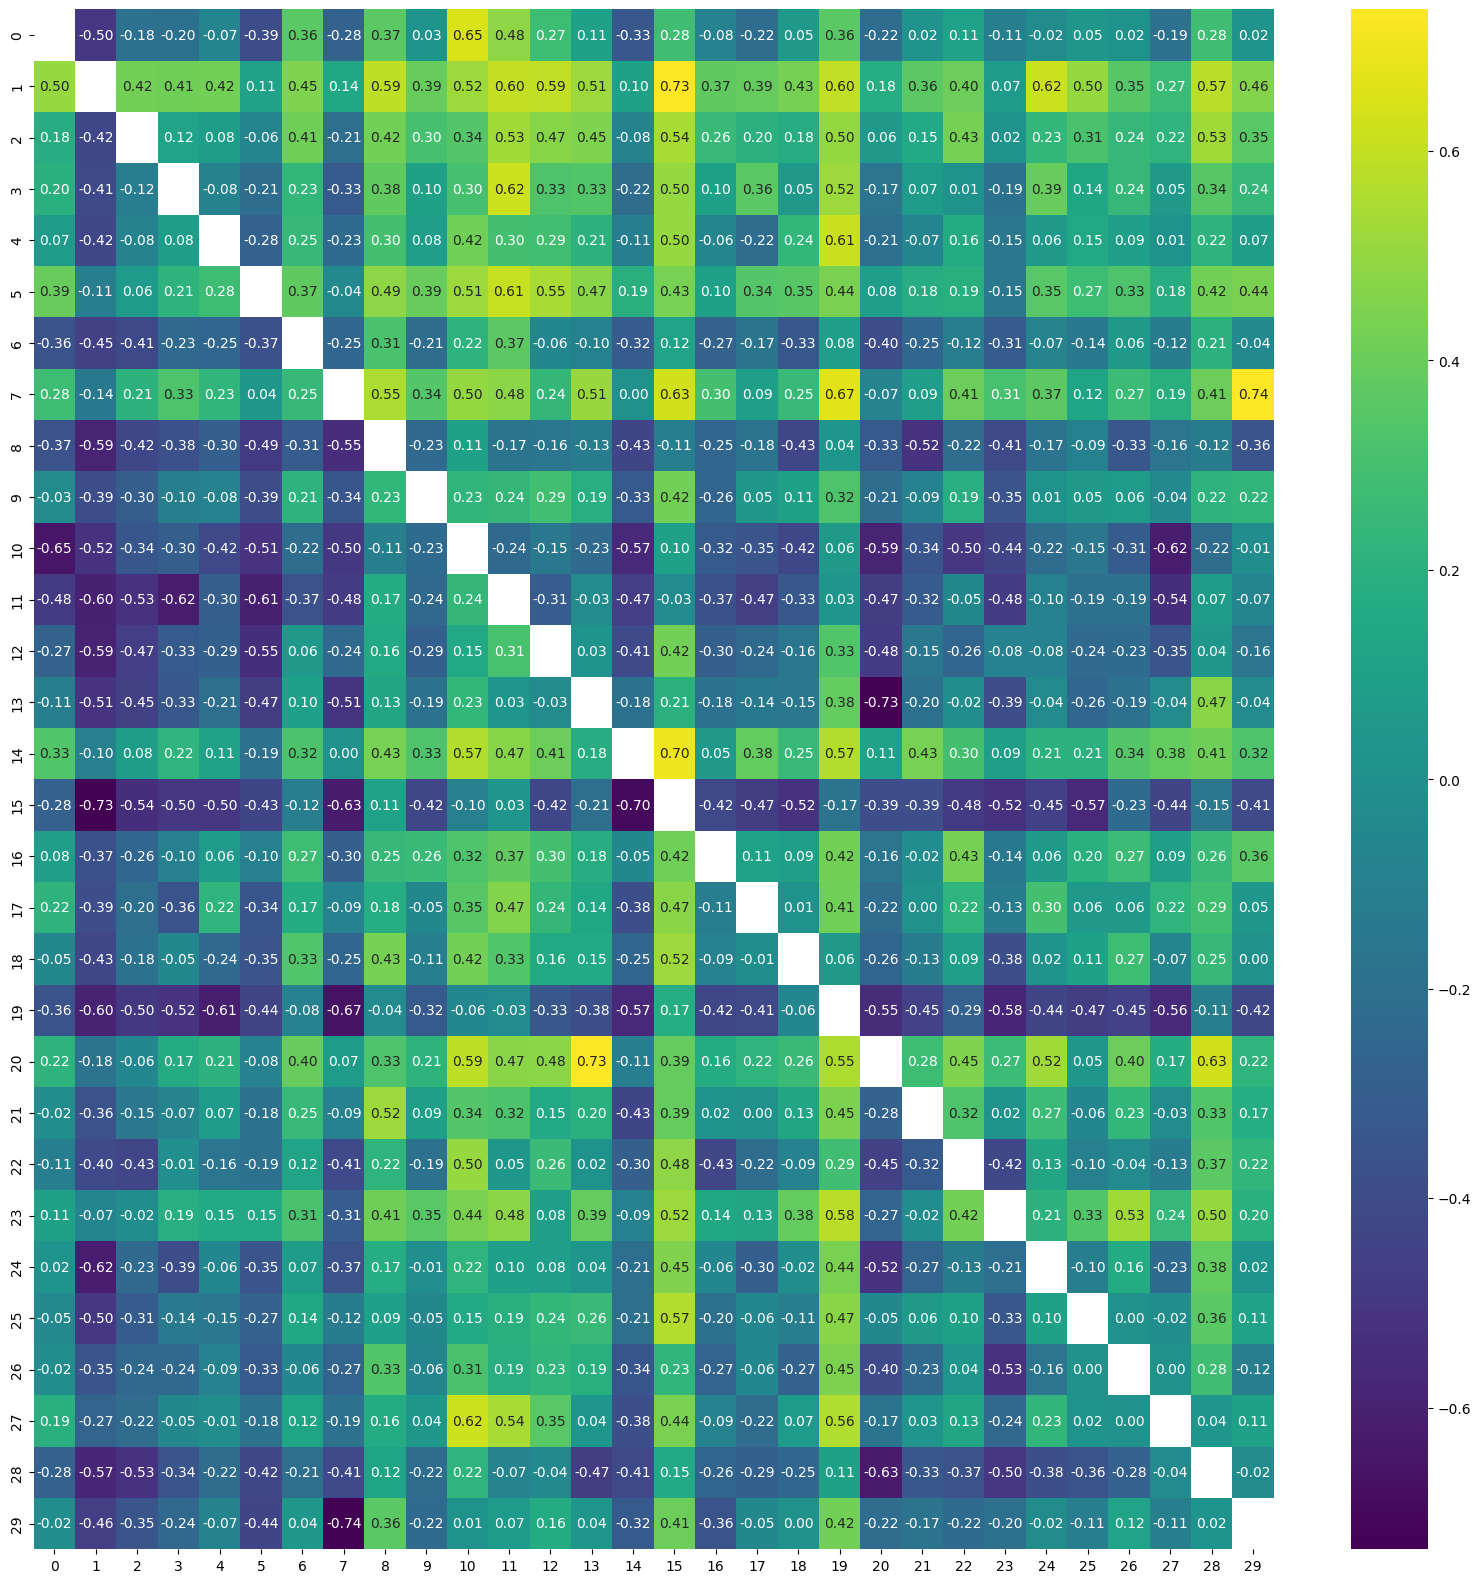

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
sns.heatmap(
    margin_wins,
    annot=True,      # show numbers in cells
    fmt=".2f",       # number format
    cmap="viridis"
)
plt.show()

## maximal lotteries from win-rate matrix

In [60]:
def maximal_lotteries_from_win_rates(
    margins,
    tie_tol=1e-12,
):
    """
    Maximal lottery from population utilities.

    Returns a mixed strategy over candidates for the majority-margin game,
    followed by candidates sorted by decreasing lottery probability.
    """
    C = margins.shape[0]

    # For skew-symmetric majority games, the value is zero. A maximal lottery
    # is any distribution p with margins.T @ p >= 0.
    result = linprog(
        c=np.zeros(C, dtype=float),
        A_ub=-margins.T,
        b_ub=np.zeros(C, dtype=float),
        A_eq=np.ones((1, C), dtype=float),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * C,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(f"Maximal lottery solve failed: {result.message}")

    lottery = np.asarray(result.x, dtype=float)
    lottery[np.abs(lottery) < tie_tol] = 0.0
    total = lottery.sum()
    if total <= 0.0:
        raise RuntimeError("Maximal lottery solve returned zero total probability.")
    lottery /= total

    ranking = np.argsort(-lottery)
    return lottery, ranking

In [62]:
np.fill_diagonal(margin_wins, 0.0)

In [63]:
lottery, ranking = maximal_lotteries_from_win_rates(margin_wins)

/tmp/ipykernel_391500/4289048897.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


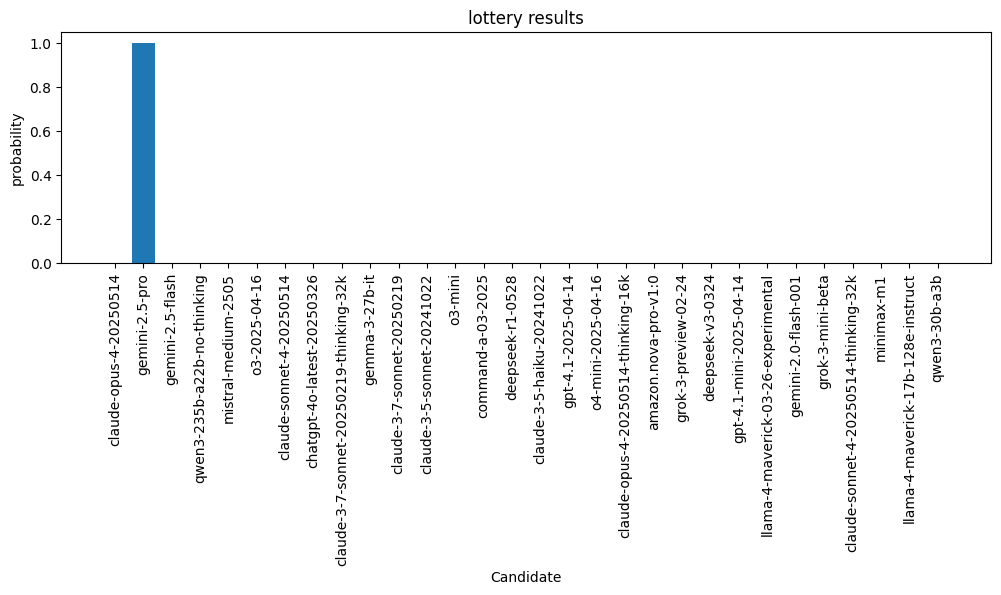

In [64]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), lottery)
    ax.set_title(f'lottery results')
    ax.set_ylabel('probability')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [93]:
def argmax_lottery_from_wins(
    margins,
    tie_tol=1e-12,
):
    """
    Peeling ranking induced by maximal lotteries from population utilities.

    At each round:
      1. Restrict to the remaining candidates
      2. Compute the infinite-sample maximal lottery on that restricted game
      3. Select the candidate with largest lottery mass
      4. Remove that candidate and repeat

    Returns:
        round_lotteries: list of length C, where round_lotteries[t] is the
            maximal lottery over the candidates remaining at round t
        ranking: array of shape (C,), candidates ordered from best to worst
    """
    # utilities = np.asarray(utilities, dtype=float)
    # if utilities.ndim != 2:
    #     raise ValueError("utilities must have shape (num_voters, num_candidates).")

    # V, C = utilities.shape
    # voter_dist = _normalize_distribution(voter_dist, V, "voter_dist")
    C = margins.shape[0]

    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        # rem_utils = utilities[:, remaining]
        rem_idx = np.asarray(remaining, dtype=int)
        rem_margins = margins[np.ix_(rem_idx, rem_idx)]
        lottery, _ = maximal_lotteries_from_win_rates(
            rem_margins,
            tie_tol=tie_tol,
        )
        round_lotteries.append(lottery.copy())

        winner_local = int(np.argmax(lottery))
        winner_global = remaining[winner_local]
        ranking.append(winner_global)
        remaining.pop(winner_local)

    return round_lotteries, np.array(ranking, dtype=int)


In [94]:
round_lotteries, ranking = argmax_lottery_from_wins(margins=margin_wins)

In [95]:
for i in range(len(round_lotteries)):
    print(f'{i}: {round_lotteries[i]}')

0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
1: [0.         0.         0.         0.         0.36085982 0.
 0.42172774 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.21741244 0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
2: [0.         0.         0.         0.         0.53109133 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.30196102 0.         0.         0.16694766 0.         0.
 0.         0.         0.         0.        ]
3: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
4: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
5: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
6: [0.         0.07055666 0.         0.         0.         0.
 0.      

In [96]:
true_ranking

array([ 1,  5,  7, 20, 14, 23,  2,  3, 16, 21,  4, 17, 27,  0, 18, 25,  9,
       26, 22, 24, 29, 13,  6, 12, 28,  8, 11, 10, 19, 15])

In [97]:
ranking

array([ 1,  7,  5, 14,  2, 20, 21, 23,  4,  3, 16,  9, 17, 27,  0, 18, 25,
       22, 24, 29,  6, 26, 12, 13, 11, 28,  8, 10, 19, 15])

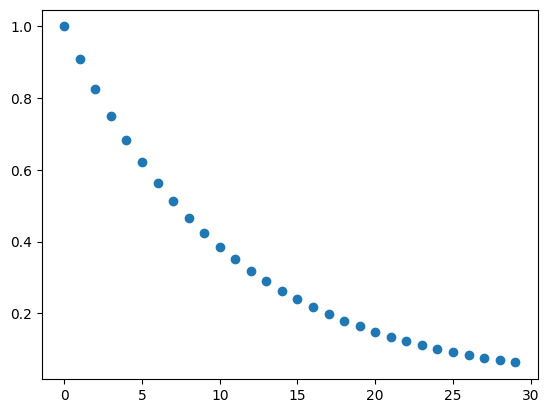

In [98]:
w = 1 / (1.1 ** np.arange(pw.M))
plt.scatter(x=np.arange(len(w)), y=w)

In [99]:
distortion, k = leaderboard_dist_w(ranking=ranking, true_ranking=true_ranking, avg_utils=population.avg_utilities, w=w)

In [100]:
distortion

np.float64(1.0036106944850636)

In [101]:
def nonzero_max_from_wins(
    margins,
    tie_tol=1e-12,
):
    """
    Peeling ranking induced by maximal lotteries from population utilities.

    At each round:
      1. Restrict to the remaining candidates
      2. Compute the infinite-sample maximal lottery on that restricted game
      3. Append every candidate with nonzero lottery mass, ordered by
         decreasing lottery probability
      4. Remove those candidates and repeat

    Returns:
        round_lotteries: list where round_lotteries[t] is the maximal lottery
            over the candidates remaining at round t
        ranking: array of shape (C,), candidates ordered from best to worst
    """
    # utilities = np.asarray(utilities, dtype=float)
    # if utilities.ndim != 2:
    #     raise ValueError("utilities must have shape (num_voters, num_candidates).")

    # V, C = utilities.shape
    # voter_dist = _normalize_distribution(voter_dist, V, "voter_dist")

    C = margins.shape[0]

    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        # rem_utils = utilities[:, remaining]
        rem_idx = np.asarray(remaining, dtype=int)
        rem_margins = margins[np.ix_(rem_idx, rem_idx)]
        lottery, ranking_local = maximal_lotteries_from_win_rates(
            rem_margins,
            tie_tol=tie_tol,
        )
        round_lotteries.append(lottery.copy())

        nonzero_local = ranking_local[lottery[ranking_local] > tie_tol]
        if nonzero_local.size == 0:
            nonzero_local = np.array([int(np.argmax(lottery))], dtype=int)

        selected_globals = [remaining[i] for i in nonzero_local]
        ranking.extend(selected_globals)

        selected_set = set(selected_globals)
        remaining = [candidate for candidate in remaining if candidate not in selected_set]

    return round_lotteries, np.array(ranking, dtype=int)

In [102]:
round_lotteries, ranking = nonzero_max_from_wins(margins=margin_wins)

In [103]:
for i in range(len(round_lotteries)):
    print(f'{i}: {round_lotteries[i]}')

0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
1: [0.         0.         0.         0.         0.36085982 0.
 0.42172774 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.21741244 0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
3: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
4: [0.         0.07055666 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.67692477 0.         0.25251857
 0.         0.         0.         0.         0.         0.        ]
5: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
6: [0.         0.13719473 0.         0.         0.62920343 0.
 0.         0.         0.         0.         0.23360184 0

In [104]:
distortion, k = leaderboard_dist_w(ranking=ranking, true_ranking=true_ranking, avg_utils=population.avg_utilities, w=w)
print(distortion)

1.0044909087337734


In [105]:
print(k)

None


## Maximal lotteries leaderboards

In [18]:
data = pw.data_by_subgroups([1533])
winners = data['winners']
losers = data['losers']

In [19]:
mask = (winners != winner) & (losers != winner)

assert len(winners[mask]) == len(losers[mask])

In [20]:
from tqdm import tqdm

In [21]:
def argmax_lottery(winners, losers, n_items, tie_tol=1e-12):
    winners = np.asarray(winners, dtype=int)
    losers = np.asarray(losers, dtype=int)

    active = np.ones(n_items, dtype=bool)
    ranking = []

    for _ in range(n_items):
        active_ids = np.flatnonzero(active)
        if active_ids.size == 0:
            break

        # Keep only comparisons among active candidates.
        mask = active[winners] & active[losers]
        w_cur = winners[mask]
        l_cur = losers[mask]

        # If no comparisons remain, append the rest arbitrarily.
        if w_cur.size == 0:
            ranking.extend(active_ids.tolist())
            break

        # Reindex active candidates to 0..k-1.
        old_to_new = -np.ones(n_items, dtype=int)
        old_to_new[active_ids] = np.arange(active_ids.size)

        w_re = old_to_new[w_cur]
        l_re = old_to_new[l_cur]

        lottery, _, winner_local, _ = maximal_lottery_from_pairwise(
            w_re,
            l_re,
            n_items=active_ids.size,
            tie_tol=tie_tol,
        )

        winner = active_ids[winner_local]
        ranking.append(winner)
        active[winner] = False

    return np.asarray(ranking, dtype=np.int64)


In [22]:
ranking = argmax_lottery(winners, losers, pw.M)

In [23]:
ranking

array([ 7, 18,  1, 23,  5, 26, 25, 20, 14,  0,  4,  2, 16, 12, 10, 21,  3,
       11, 22, 29,  8, 24, 13,  6, 17, 28, 27, 15,  9, 19])

## Distortion of argmax lottery leaderboard

In [24]:
def leaderboard_dist(ranking, true_ranking, avg_utils):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]

    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum = np.cumsum(true_ranking_utils)

    ratio = np.max(num_cumsum / denom_cumsum)
    k = np.argmax(num_cumsum / denom_cumsum)
    return ratio, k

In [25]:
ratio, k = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
print(ratio)

1.3230116303189503


## Infinite sample approximation

In [28]:
from utils_3 import maximal_lotteries_from_population_utilities

lottery, ranking = maximal_lotteries_from_population_utilities(
    utilities=population.population_utilities,
    voter_dist=population.voter_distr,
    beta=1.0,
)

winner = ranking[0]
print(lottery)
print(ranking)
print(winner)


[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[ 1  0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
1


In [29]:
population.voter_distr.sum()

np.float64(1.0)

In [30]:
def argmax_lottery_from_population_utilities(
    utilities,
    voter_dist=None,
    beta=1.0,
    tie_tol=1e-12,
):
    """
    Peeling ranking induced by maximal lotteries from population utilities.

    At each round:
      1. Restrict to the remaining candidates
      2. Compute the infinite-sample maximal lottery on that restricted game
      3. Select the candidate with largest lottery mass
      4. Remove that candidate and repeat

    Returns:
        round_lotteries: list of length C, where round_lotteries[t] is the
            maximal lottery over the candidates remaining at round t
        ranking: array of shape (C,), candidates ordered from best to worst
    """
    utilities = np.asarray(utilities, dtype=float)
    if utilities.ndim != 2:
        raise ValueError("utilities must have shape (num_voters, num_candidates).")

    V, C = utilities.shape
    # voter_dist = _normalize_distribution(voter_dist, V, "voter_dist")

    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        rem_utils = utilities[:, remaining]
        lottery, _ = maximal_lotteries_from_population_utilities(
            rem_utils,
            voter_dist=voter_dist,
            beta=beta,
            tie_tol=tie_tol,
        )
        round_lotteries.append(lottery.copy())

        winner_local = int(np.argmax(lottery))
        winner_global = remaining[winner_local]
        ranking.append(winner_global)
        remaining.pop(winner_local)

    return round_lotteries, np.array(ranking, dtype=int)


In [31]:
round_lotteries, ranking = argmax_lottery_from_population_utilities(
    utilities=population.population_utilities,
    voter_dist=population.voter_distr,
    beta=1.0,
)

In [32]:
ranking

array([ 1,  5,  7, 20, 14, 23,  2,  3, 16, 21,  4, 17, 27,  0, 18, 25,  9,
       26, 22, 24, 29, 13,  6, 12, 28,  8, 11, 10, 19, 15])

In [33]:
ratio, k = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
print(ratio)

1.0


[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
0.01 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
0.1 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
0.5 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
1.0 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
2.0 [ 1  5  7 20 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0011062825885348 k: 12
3 [ 1  7  5 20 14 23  2  3 16 21  4 17  0 27 18  9 25 22 26 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0047482962757752 k: 1
5.0 [ 1 20  7  5 14 23  2  3 16  4 21 17  0  9 27 18 25 22 26 24 29  6 13 12
 28  8 11 10 19 15] distortion: 1.0099553753099328 k: 1
10.0 [ 1 20  7  5 14  2 23 16  3  4 

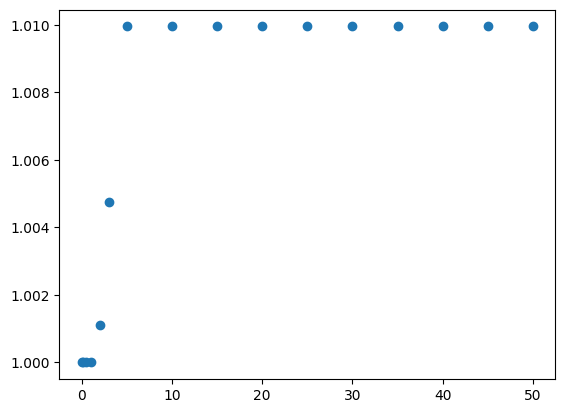

In [34]:
betas = [0.01, 0.1, 0.5, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50]
ml_ld = []
round_lotteries = []

print(true_ranking)

for beta in betas:
    round_lotteries, ranking = argmax_lottery_from_population_utilities(
        utilities=population.population_utilities,
        voter_dist=population.voter_distr,
        beta=beta,
    )
    distortion, k = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
    print(beta, ranking,f'distortion: {distortion}', f'k: {k}')
    ml_ld.append(distortion)
    round_lotteries


plt.scatter(x=np.asarray(betas), y=np.asarray(ml_ld))
plt.show()

In [35]:
round_lotteries, ranking = argmax_lottery_from_population_utilities(
        utilities=population.population_utilities,
        voter_dist=population.voter_distr,
        beta=15.0,
    )

In [36]:
for i, r in enumerate(round_lotteries):
    print(f'round {i}: {r}')

round 0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
round 1: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
round 2: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
round 3: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
round 4: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
round 5: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
round 6: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
round 7: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
round 8: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
round 9: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
round 10: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
round 11: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

round_lotteries = np.asarray(round_lotteries)

plt.figure(figsize=(8, 6))
sns.heatmap(
    round_lotteries,
    annot=True,      # show numbers in cells
    fmt=".2f",       # number format
    cmap="viridis"
)
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (30,) + inhomogeneous part.

## Fixed weight set

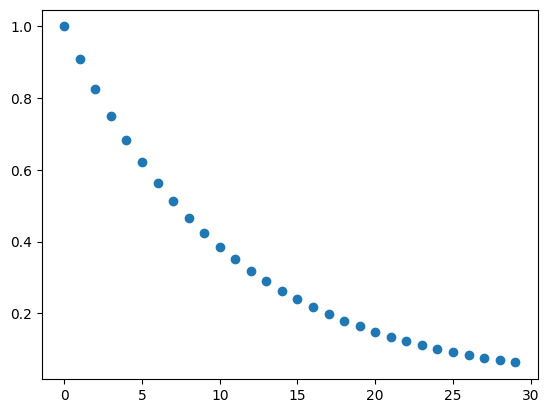

In [47]:
w = 1 / (1.1 ** np.arange(pw.M))
plt.scatter(x=np.arange(len(w)), y=w)

In [48]:
def leaderboard_dist_w(ranking, true_ranking, avg_utils, w):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]

    num = true_ranking_utils * w
    denom = ranking_utils * w

    ratio = num.sum() / denom.sum()

    return ratio, None

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]


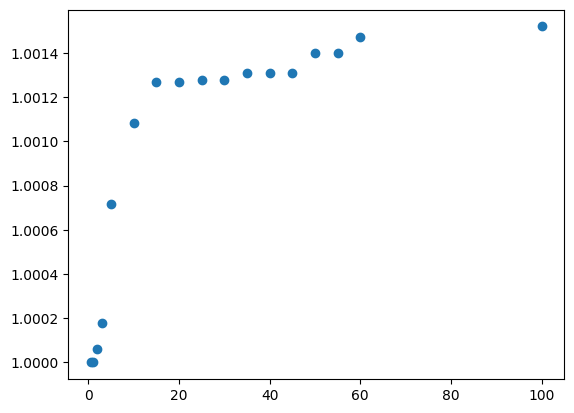

In [49]:
betas = [0.5, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50, 55, 60, 100]
ml_ld = []

print(true_ranking)

for beta in betas:
    round_lotteries, ranking = argmax_lottery_from_population_utilities(
        utilities=population.population_utilities,
        voter_dist=population.voter_distr,
        beta=beta,
    )
    distortion, k = leaderboard_dist_w(ranking, true_ranking, population.avg_utilities, w)
    ml_ld.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(ml_ld))
plt.show()

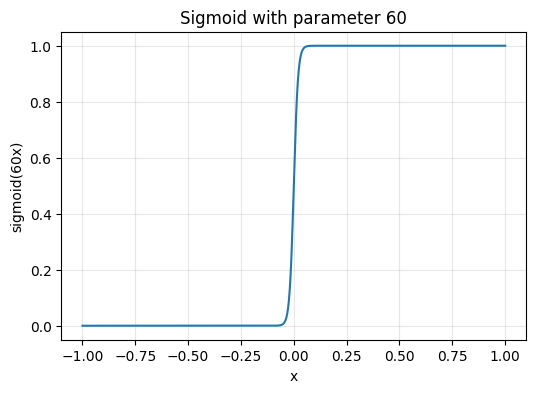

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

x = np.linspace(-1, 1, 1000)
y = expit(100.0 * x)

plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("sigmoid(60x)")
plt.title("Sigmoid with parameter 60")
plt.grid(True, alpha=0.3)
plt.show()


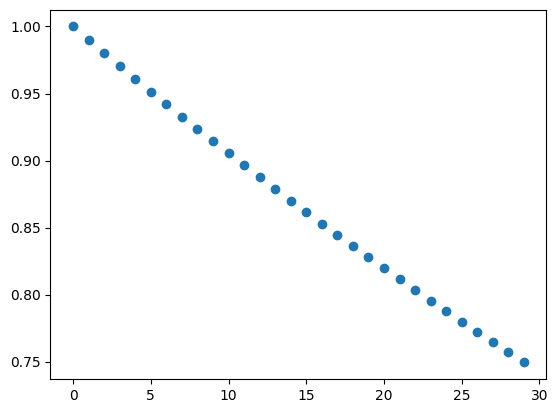

In [51]:
w = 1 / (1.01 ** np.arange(pw.M))
plt.scatter(x=np.arange(len(w)), y=w)

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]


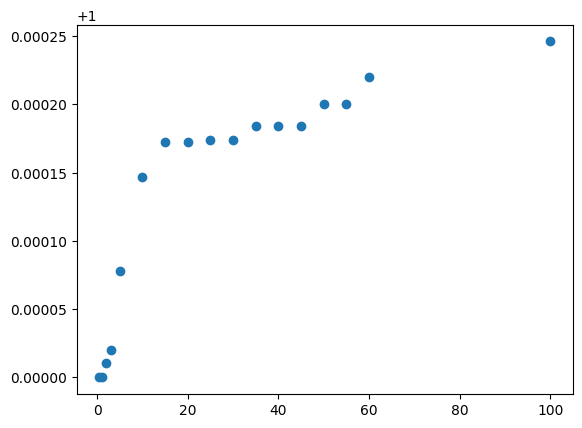

In [52]:
betas = [0.5, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50, 55, 60, 100]
ml_ld = []

print(true_ranking)

for beta in betas:
    round_lotteries, ranking = argmax_lottery_from_population_utilities(
        utilities=population.population_utilities,
        voter_dist=population.voter_distr,
        beta=beta,
    )
    distortion, k = leaderboard_dist_w(ranking, true_ranking, population.avg_utilities, w)
    ml_ld.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(ml_ld))
plt.show()

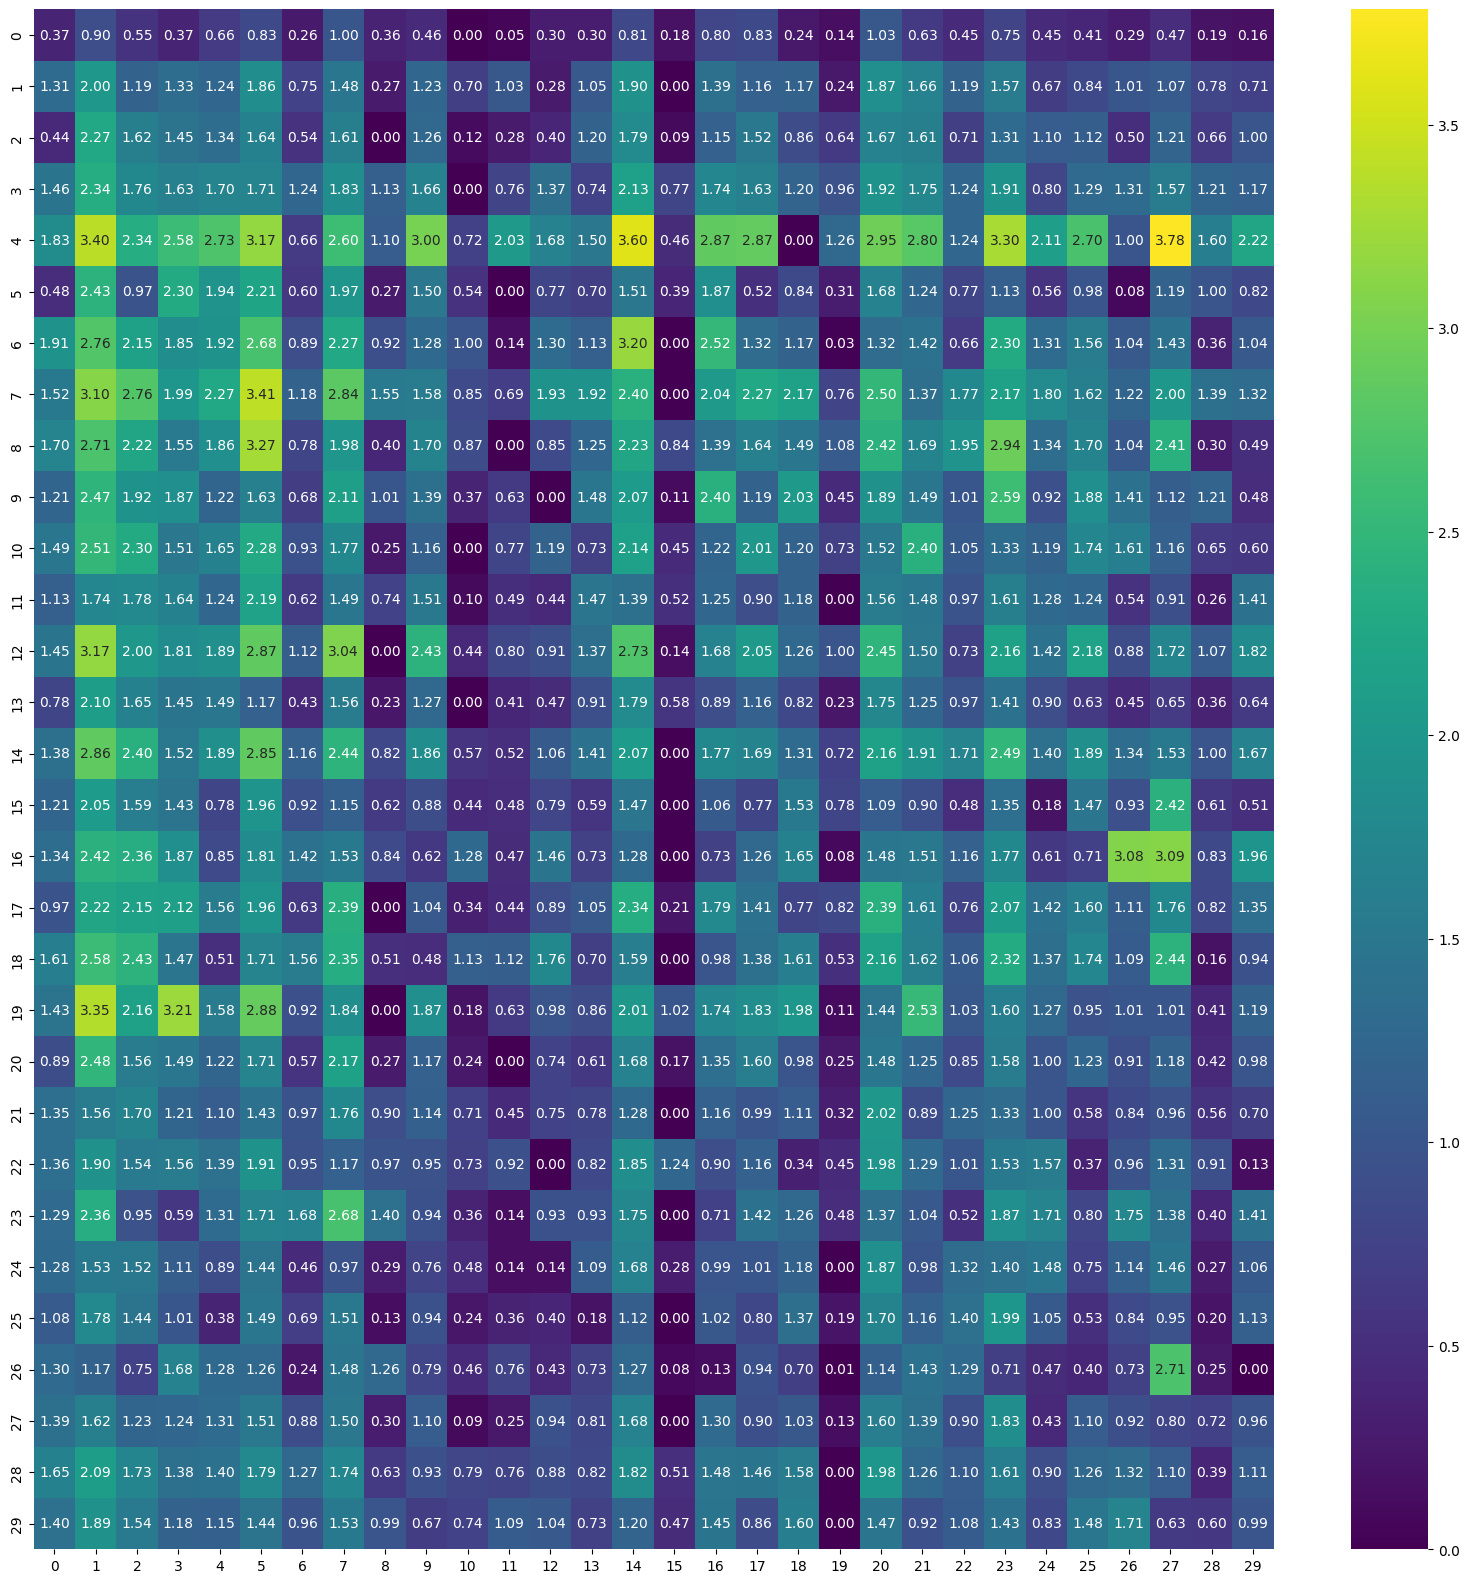

In [41]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    population.population_utilities,
    annot=True,      # show numbers in cells
    fmt=".2f",       # number format
    cmap="viridis"
)
plt.show()

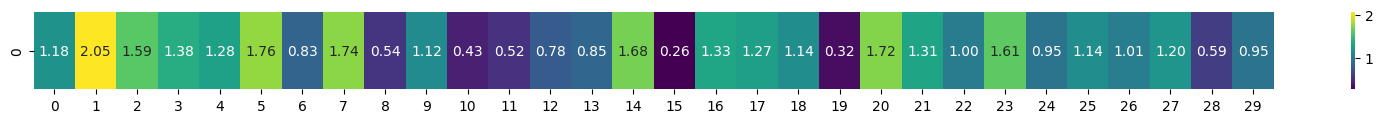

In [42]:
plt.figure(figsize=(20, 1))
sns.heatmap(
    population.avg_utilities[None],
    annot=True,      # show numbers in cells
    fmt=".2f",       # number format
    cmap="viridis"
)
plt.show()

In [43]:
def nonzero_max_from_population_utilities(
    utilities,
    voter_dist=None,
    beta=1.0,
    tie_tol=1e-12,
):
    """
    Peeling ranking induced by maximal lotteries from population utilities.

    At each round:
      1. Restrict to the remaining candidates
      2. Compute the infinite-sample maximal lottery on that restricted game
      3. Append every candidate with nonzero lottery mass, ordered by
         decreasing lottery probability
      4. Remove those candidates and repeat

    Returns:
        round_lotteries: list where round_lotteries[t] is the maximal lottery
            over the candidates remaining at round t
        ranking: array of shape (C,), candidates ordered from best to worst
    """
    utilities = np.asarray(utilities, dtype=float)
    if utilities.ndim != 2:
        raise ValueError("utilities must have shape (num_voters, num_candidates).")

    V, C = utilities.shape
    # voter_dist = _normalize_distribution(voter_dist, V, "voter_dist")

    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        rem_utils = utilities[:, remaining]
        lottery, ranking_local = maximal_lotteries_from_population_utilities(
            rem_utils,
            voter_dist=voter_dist,
            beta=beta,
            tie_tol=tie_tol,
        )
        round_lotteries.append(lottery.copy())

        nonzero_local = ranking_local[lottery[ranking_local] > tie_tol]
        if nonzero_local.size == 0:
            nonzero_local = np.array([int(np.argmax(lottery))], dtype=int)

        selected_globals = [remaining[i] for i in nonzero_local]
        ranking.extend(selected_globals)

        selected_set = set(selected_globals)
        remaining = [candidate for candidate in remaining if candidate not in selected_set]

    return round_lotteries, np.array(ranking, dtype=int)

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
0.01 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
0.1 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
0.5 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
1.0 [ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0 k: 0
2.0 [ 1  5  7 20 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0011062825885348 k: 12
3 [ 1  7  5 20 14 23  2  3 16 21  4 17  0 27 18  9 25 22 26 24 29 13  6 12
 28  8 11 10 19 15] distortion: 1.0047482962757752 k: 1
5.0 [ 1 20  7  5 14 23  2  3 16  4 21 17  0  9 27 18 25 22 26 24 29  6 13 12
 28  8 11 10 19 15] distortion: 1.0099553753099328 k: 1
10.0 [ 1 20  7  5 14  2 23 16  3  4 

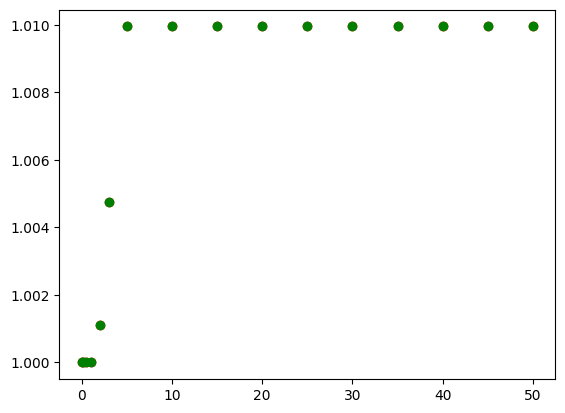

In [44]:
betas = [0.01, 0.1, 0.5, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50]
arg_max_ml_ld = []
non_zero_ml_ld = []

print(true_ranking)

for beta in betas:
    round_lotteries, ranking = nonzero_max_from_population_utilities(
        utilities=population.population_utilities,
        voter_dist=population.voter_distr,
        beta=beta,
    )
    distortion, k = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
    non_zero_ml_ld.append(distortion)


# plt.scatter(x=np.asarray(betas), y=np.asarray(ml_ld))
# plt.show()


# betas = [0.01, 0.1, 0.5, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50]
# round_lotteries = []

# print(true_ranking)

for beta in betas:
    round_lotteries, ranking = argmax_lottery_from_population_utilities(
        utilities=population.population_utilities,
        voter_dist=population.voter_distr,
        beta=beta,
    )
    distortion, k = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
    print(beta, ranking,f'distortion: {distortion}', f'k: {k}')
    arg_max_ml_ld.append(distortion)
    # round_lotteries


plt.scatter(x=np.asarray(betas), y=np.asarray(arg_max_ml_ld), c='red')
plt.scatter(x=np.asarray(betas), y=np.asarray(non_zero_ml_ld), c='green')
plt.show()

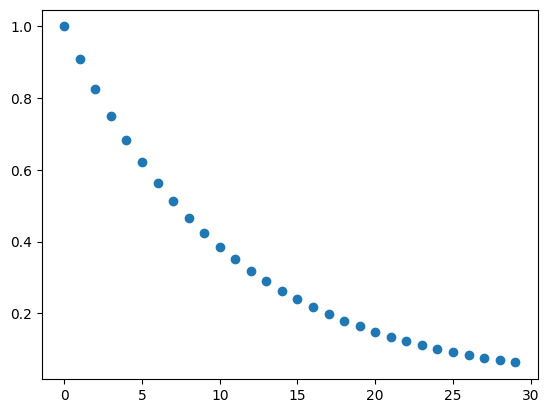

In [45]:
w = 1 / (1.1 ** np.arange(pw.M))
plt.scatter(x=np.arange(len(w)), y=w)

In [46]:
betas = [0.1, 0.5, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50, 80, 100]
ml_ld = []

print(true_ranking)

for beta in betas:
    round_lotteries, ranking = nonzero_max_from_population_utilities(
        utilities=population.population_utilities,
        voter_dist=population.voter_distr,
        beta=beta,
    )
    distortion, k = leaderboard_dist_w(ranking, true_ranking, population.avg_utilities, w=w)
    ml_ld.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(ml_ld))
plt.show()

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]


NameError: name 'leaderboard_dist_w' is not defined

In [ ]:
import numpy as np
from utils_3 import maximal_lottery_from_population_utilities

def probabilistic_distortion_with_maximal_lottery(utilities, voter_dist=None, beta=1.0):
    # Compute maximal lottery
    lottery, _ = maximal_lottery_from_population_utilities(
        utilities=utilities, voter_dist=voter_dist, beta=beta
    )
    
    # Compute average utilities
    avg_utility = utilities.mean(axis=0)
    
    # True winner
    true_winner = int(np.argmax(avg_utility))
    true_winner_utility = float(avg_utility[true_winner])
    
    # Expected utility under lottery
    expected_utility = np.sum(lottery * avg_utility)
    
    # Distortion
    if true_winner_utility == 0.0:
        distortion = np.nan
    else:
        distortion = expected_utility / true_winner_utility
    
    return {
        "true_winner": true_winner,
        "true_winner_avg_utility": true_winner_utility,
        "expected_selected_utility": expected_utility,
        "lottery": lottery,
        "distortion": distortion,
    }

In [ ]:
outcome = probabilistic_distortion_with_maximal_lottery# (
    population.population_utilities, 
    voter_dist=population.voter_distr, 
    beta=1.0
)

In [ ]:
outcome['distortion']

np.float64(1.0)

In [ ]:
#